# Brazil E-Commerce — Order Reviews Analysis

Analysis of the **Olist `olist_order_reviews_dataset.csv`** file.

Columns:
- `review_id` — unique review identifier
- `order_id` — key to the orders dataset
- `review_score` — 1 to 5 star rating
- `review_comment_title` — optional free-text title
- `review_comment_message` — optional free-text message
- `review_creation_date` — when the review survey was sent
- `review_answer_timestamp` — when the customer answered

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

## 1. Load the data

In [2]:
reviews = pd.read_csv(
    "Data/olist_order_reviews_dataset.csv",
    parse_dates=["review_creation_date", "review_answer_timestamp"],
)
print(f"Shape: {reviews.shape[0]:,} rows x {reviews.shape[1]} columns")
reviews.head()

Shape: 99,224 rows x 7 columns


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


In [3]:
reviews.info()
reviews.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  str           
 1   order_id                 99224 non-null  str           
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  str           
 4   review_comment_message   40977 non-null  str           
 5   review_creation_date     99224 non-null  datetime64[us]
 6   review_answer_timestamp  99224 non-null  datetime64[us]
dtypes: datetime64[us](2), int64(1), str(4)
memory usage: 5.3 MB


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,99224.000000,11568,40977,99224,99224
unique,98410,98673,NaN,4527,36159,NaN,NaN
top,c444278834184f72b1484dfe47de7f97,c88b1d1b157a9999ce368f218a407141,NaN,Recomendo,Muito bom,NaN,NaN
freq,3,3,NaN,423,230,NaN,NaN
mean,NaN,NaN,4.086421,NaN,NaN,2018-01-12 20:49:23.948238,2018-01-16 00:23:56.977939
min,NaN,NaN,1.000000,NaN,NaN,2016-10-02 00:00:00,2016-10-07 18:32:28
25%,NaN,NaN,4.000000,NaN,NaN,2017-09-23 00:00:00,2017-09-27 01:53:27.250000
50%,NaN,NaN,5.000000,NaN,NaN,2018-02-02 00:00:00,2018-02-04 22:41:47.500000
75%,NaN,NaN,5.000000,NaN,NaN,2018-05-16 00:00:00,2018-05-20 12:11:21.500000
max,NaN,NaN,5.000000,NaN,NaN,2018-08-31 00:00:00,2018-10-29 12:27:35


## 2. Data quality checks

In [4]:
print("Missing values per column:")
print(reviews.isna().sum())

print(f"\nFully duplicated rows: {reviews.duplicated().sum():,}")
print(f"Distinct review_id: {reviews['review_id'].nunique():,}")
print(f"Distinct order_id:  {reviews['order_id'].nunique():,}")
has_title = reviews['review_comment_title'].notna().mean()
has_msg = reviews['review_comment_message'].notna().mean()
print(f"Reviews with a title:   {has_title:.1%}")
print(f"Reviews with a message: {has_msg:.1%}")

Missing values per column:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64



Fully duplicated rows: 0
Distinct review_id: 98,410
Distinct order_id:  98,673
Reviews with a title:   11.7%
Reviews with a message: 41.3%


## 3. Review score distribution

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Mean score: 4.09


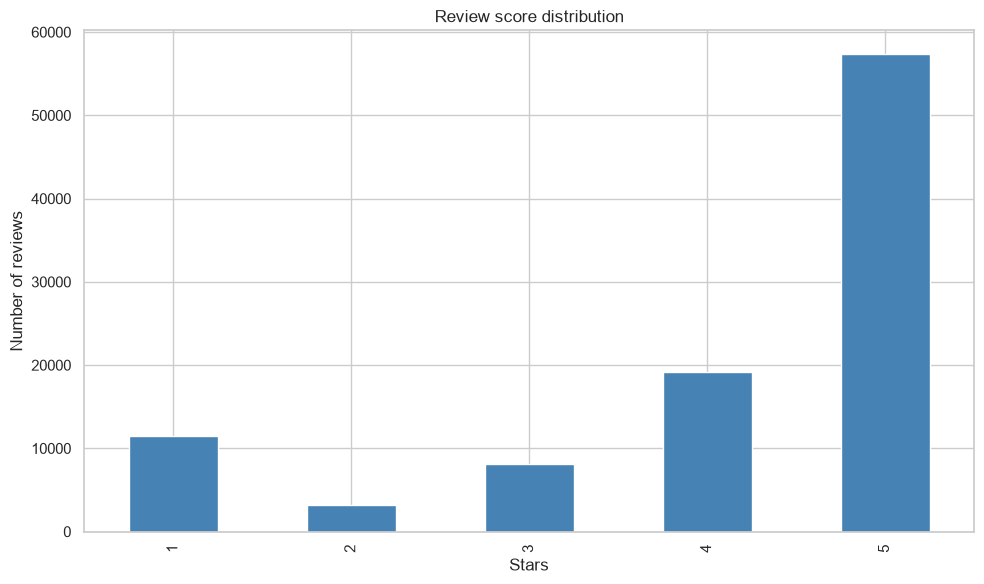

In [5]:
scores = reviews["review_score"].value_counts().sort_index()
print(scores)
print(f"\nMean score: {reviews['review_score'].mean():.2f}")

ax = scores.plot(kind="bar", color="steelblue")
ax.set_title("Review score distribution")
ax.set_xlabel("Stars")
ax.set_ylabel("Number of reviews")
plt.tight_layout()
plt.show()

## 4. Do customers comment more when unhappy?

review_score
1    0.765494
2    0.680736
3    0.434894
4    0.312193
5    0.358533
Name: has_message, dtype: float64


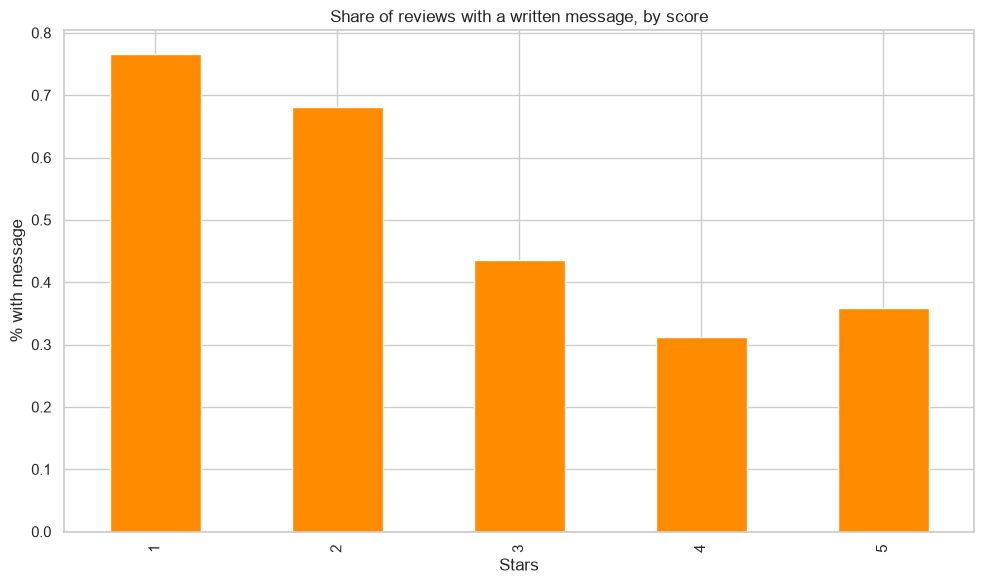

In [6]:
reviews["has_message"] = reviews["review_comment_message"].notna()
comment_rate = reviews.groupby("review_score")["has_message"].mean()
print(comment_rate)

ax = comment_rate.plot(kind="bar", color="darkorange")
ax.set_title("Share of reviews with a written message, by score")
ax.set_xlabel("Stars")
ax.set_ylabel("% with message")
plt.tight_layout()
plt.show()

## 5. Review response time

count    99224.000000
mean         3.148993
std          9.890049
min          0.089225
25%          1.004870
50%          1.674948
75%          3.103565
max        518.699213
Name: response_days, dtype: float64


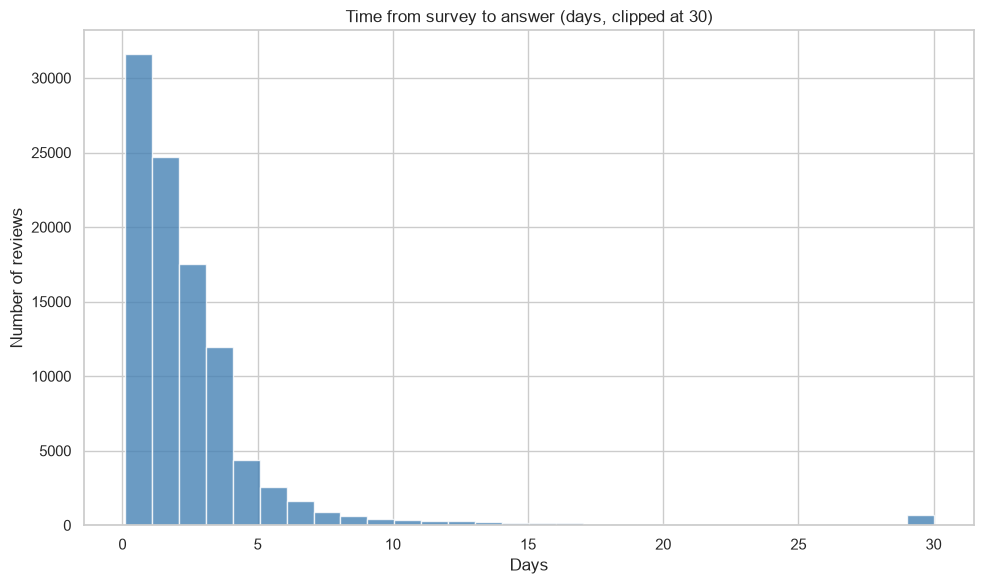

In [7]:
reviews["response_days"] = (
    reviews["review_answer_timestamp"] - reviews["review_creation_date"]
).dt.total_seconds() / 86400
print(reviews["response_days"].describe())

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(reviews["response_days"].clip(0, 30), bins=30, color="steelblue", alpha=0.8)
ax.set_title("Time from survey to answer (days, clipped at 30)")
ax.set_xlabel("Days")
ax.set_ylabel("Number of reviews")
plt.tight_layout()
plt.show()

## 6. Reviews over time

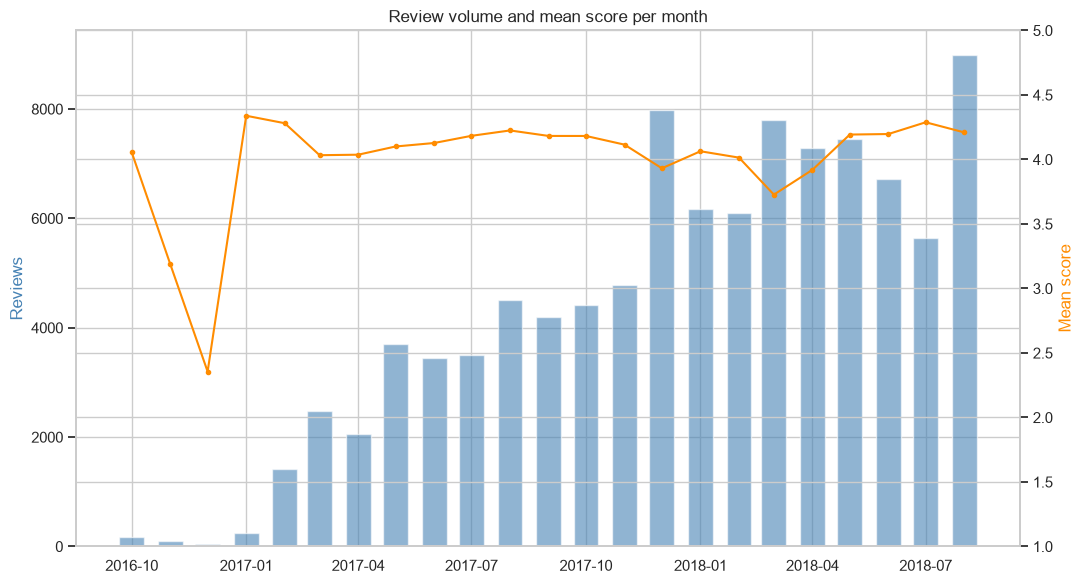

In [8]:
monthly = (
    reviews.set_index("review_creation_date")
    .resample("MS")["review_score"]
    .agg(["count", "mean"])
)
fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.bar(monthly.index, monthly["count"], width=20, color="steelblue", alpha=0.6, label="reviews")
ax1.set_ylabel("Reviews", color="steelblue")
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["mean"], color="darkorange", marker="o", ms=3, label="mean score")
ax2.set_ylabel("Mean score", color="darkorange")
ax2.set_ylim(1, 5)
ax1.set_title("Review volume and mean score per month")
plt.tight_layout()
plt.show()

## 7. Key takeaways

_Fill in after running the cells above. Typical findings for this dataset:_

- Scores are heavily skewed toward 5 stars, with a secondary spike at 1 star (J-shaped).
- Most reviews have no written message; comments are more likely on low scores.
- Customers typically answer the survey within a few days of receiving it.